[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A6_finance_ar_cashflow.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's sixth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A6 (IA) — Finance: Late Invoices, Collections & the 13-Week Cash Forecast

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

A3 ended in a victory: the B2B webshop's **"Invoice 30"** trade-credit program shipped with a scorecard, a `PD*` cutoff, and an approval rate near **89 %**. This notebook is the bill for that victory. Every approved order became an invoice, every invoice became a promise, and the promises now sit on the balance sheet as a **€4.2M accounts-receivable book** — money the company has earned, booked as revenue, and does not have. A3 decided *who gets credit*; this notebook manages *what happens next*: when the cash actually arrives, which late payers are worth a phone call, and whether the company clears the quarter without touching its credit line.

The cast: a CFO who asks the same question every Monday morning — *"how much cash lands this quarter, and do we need to draw the line?"* — and a two-person collections team that can make about **40 dunning calls a week** into a book of ~800 open invoices. Both questions are prediction problems wearing finance clothes, and both are usually answered with a spreadsheet that assumes everyone pays on the due date. Nobody pays on the due date. One boundary before we start: an invoice that pays 40 days late is a *collections* problem; an invoice that was never going to pay because the "customer" was fabricated is **NB 24's fraud problem** — different features, different adversary, different notebook. Here everyone is real; some are just slow, and a few go under.

> 🧠 **Mental model.** An AR ledger is a *portfolio of forecastable delays*. Each invoice has a due date (a fiction), a realized payment date (the fact), and the gap between them is surprisingly predictable — because payment behaviour is a property of the **customer**, not of the invoice. Everything in this notebook is the same move applied three ways: predict the gap per invoice, then aggregate — into a call list (§3), into a 13-week cash curve (§4), into an honest backtest of that curve (§5). The money is made in the aggregation, and lost in the optimism.


## 🎯 Learning objectives

By the end you can:

1. Read an **AR ledger** the way finance does — aging waterfall, DSO, and what one day of DSO is worth in cash at a given book size.
2. Predict **days-late per invoice** with as-of features (customer history reconstructed at issue date, NB 26's shifted-window discipline), and beat two baselines you must name: *"everyone pays on the due date"* and *"the customer's own historical mean"*.
3. Build a **collections queue** ranked by expected cash acceleration in euros — not by amount, not by days overdue — sized to 40 calls/week, and explain why the biggest overdue invoice is often the worst call.
4. Turn the scored ledger into a **13-week cash-flow forecast**: per-invoice payment-date *distributions* (not point estimates), a seasonal-naive layer for invoices that don't exist yet, fixed outflows, and a Monte Carlo band that answers *"P(we dip below the €250k buffer)?"* with a number.
5. **Backtest a cash forecast honestly** — walk-forward from four historical Mondays — and quantify, in euros, how optimistic the due-date spreadsheet is and why.
6. Say what real treasury systems add (payment-run calendars, remittance data, dunning ladders, dynamic discounting) and price a *2/10 net 30* offer against the cost of capital in one line.

## ✅ Prerequisites

**A3** (this is its direct sequel — the AR book below is what A3's approvals became), **NB 26** (seasonal-naive forecasting, shifted rolling features — both reappear here doing finance jobs), **NB 24** (the capacity-sized queue pattern; also the fraud boundary), **NB 23** (expected-value targeting), **NB 18** (calibration, honest evaluation). **A2** helps for reading the uncertainty bands. All data is generated inline; everything runs offline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

TODAY = pd.Timestamp("2025-06-30")     # this notebook's Monday morning
R_ANNUAL = 0.08                        # cost of capital -- what idle receivables cost us
R_DAY = R_ANNUAL / 365
BUFFER = 250_000.0                     # treasury policy: never plan below this cash level
START_CASH = 760_000.0                 # in the bank this Monday
CALLS_PER_WEEK = 40                    # two collectors, ~20 calls each per week
CALL_COST = 15.0                       # loaded cost of one dunning call
CALL_PULL = 12                         # a successful call moves payment forward ~12 days
P_SUCCESS = 0.55                       # ...and works slightly more often than not

print(f"Cash today EUR {START_CASH:,.0f}, buffer EUR {BUFFER:,.0f}; capital costs {R_ANNUAL:.0%}/yr.")
print(f"Collections capacity: {CALLS_PER_WEEK} calls/week at EUR {CALL_COST:.0f} each; "
      f"a call pulls payment ~{CALL_PULL} days forward with {P_SUCCESS:.0%} success.")

Cash today EUR 760,000, buffer EUR 250,000; capital costs 8%/yr.
Collections capacity: 40 calls/week at EUR 15 each; a call pulls payment ~12 days forward with 55% success.


## 1. The business: a €4.2M ledger, a credit line, and Monday's question

Eighteen months after "Invoice 30" launched, the webshop's finance team owns a ledger of roughly **9,000 invoices across ~600 business customers** — office and IT supplies, invoiced on **Net 30** mostly, Net 14 for some of the small accounts, Net 60 for the large ones who demanded it and got it. Sales spike at quarter-end (procurement budgets expire; A1 met the same seasonality from the pricing side), and payments come back with all the texture real AR has:

- **Payment behaviour is a customer trait.** Some firms pay early, some pay 25 days late *every single time* — chronic offenders are a personality, not an accident.
- **Big customers pay slower, but reliably.** A large account on Net 60 that settles 12 days late like clockwork is a scheduling fact, not a risk.
- **Month-end payment runs.** A large share of German B2B customers pay invoices in one batch on the last day of the month — whatever day the invoice was actually due. Keep an eye on this one; it will smear every per-day forecast we ever attempt.
- **A small insolvency tail.** About 1 % of invoices never pay at all. This is A3's PD made flesh: the write-offs below are exactly the losses the scorecard's cutoff accepted as the price of approving ~89 % of applicants. (Anything that smells fabricated rather than slow is NB 24's beat, not ours.)

We generate the ledger inline as usual — seeded, offline, with the ground truth planted so we can later check what our estimates should have found.


In [2]:
def build_ledger(seed=7, n_cust=600):
    """18 months of the Invoice-30 AR ledger: invoices, due dates, realized payments."""
    rng = np.random.default_rng(seed)

    # ---- customers: size, payment culture, batching, insolvency risk ----
    size = rng.choice(["small", "mid", "large"], n_cust, p=[0.55, 0.35, 0.10])
    s_small, s_mid, s_large = size == "small", size == "mid", size == "large"
    mu = np.where(s_small, rng.normal(3, 5, n_cust),          # mean days vs due date
         np.where(s_mid, rng.normal(6, 5, n_cust), rng.normal(12, 3, n_cust)))
    chronic = (rng.random(n_cust) < 0.15) & ~s_large          # the chronic late payers
    mu = mu + np.where(chronic, 17, 0)
    sigma = np.where(s_large, 4.0, np.where(s_mid, 8.0, 10.0))  # large = slow but reliable
    batcher = rng.random(n_cust) < 0.40                       # pays on month-end runs
    p_wo_cust = np.where(s_large, 0.001, np.where(chronic, 0.035, 0.006))  # insolvency
    activity = rng.gamma(2.0, 1.0, n_cust) * np.where(s_large, 2.2, np.where(s_mid, 1.3, 1.0))
    amt_med = np.where(s_small, 850, np.where(s_mid, 2700, 11500))

    # ---- invoices: quarter-end issuance spikes, mild month-end weighting ----
    months = pd.period_range("2024-01", "2025-06", freq="M")
    q_end = np.array([1.38 if m.month in (3, 6, 9, 12) else 1.0 for m in months])
    lam = 9000 / q_end.sum() * q_end
    rows = []
    for m, lam_m in zip(months, lam):
        n_m = rng.poisson(lam_m)
        cust = rng.choice(n_cust, n_m, p=activity / activity.sum())
        dim = m.days_in_month
        day = np.where(rng.random(n_m) < 0.35,
                       rng.integers(dim - 9, dim + 1, n_m),   # a chunk lands late-month
                       rng.integers(1, dim + 1, n_m))
        rows.append(pd.DataFrame({"customer_id": cust, "issue_date": pd.to_datetime(
            {"year": m.year, "month": m.month, "day": day})}))
    inv = pd.concat(rows, ignore_index=True)
    n, c = len(inv), inv.customer_id.to_numpy()

    inv["size"] = size[c]
    u = rng.random(n)                                          # terms by size
    inv["terms"] = np.where(size[c] == "large", np.where(u < 0.45, 60, 30),
                            np.where(u < 0.15, 14, np.where(u < 0.90, 30, 60)))
    inv["amount"] = np.round(np.exp(rng.normal(np.log(amt_med[c]), 0.65, n)), 2)
    inv["due_date"] = inv.issue_date + pd.to_timedelta(inv.terms, unit="D")

    # ---- days late: persistence + amount effect + quarter-end drag + disputes ----
    amt_eff = 1.6 * np.log(inv.amount / 3000).clip(-1.5, 2.5)  # big invoices sit longer
    qe_drag = np.where(inv.issue_date.dt.month.isin([3, 6, 9, 12])
                       & (inv.issue_date.dt.day > 20), 2.5, 0.0)
    disputed = rng.random(n) < 0.03                            # stuck in a query: +6-10 wks
    dlate = (mu[c] + amt_eff + qe_drag + disputed * rng.normal(52, 12, n)
             + rng.normal(0, sigma[c], n))
    dlate = np.maximum(dlate, -(inv.terms - 2))                # can't pay before ~issue
    pay = inv.due_date + pd.to_timedelta(np.round(dlate), unit="D")

    # ---- month-end payment runs: batchers pay on the last day of the month ----
    is_b = batcher[c]
    pay = pay.where(~is_b, pay.dt.to_period("M").dt.end_time.dt.normalize())

    # ---- the insolvency tail: ~1% of invoices never pay ----
    wo = rng.random(n) < p_wo_cust[c]
    inv["paid_date"] = pay.where(~wo, pd.NaT)
    inv["days_late"] = np.where(wo, np.nan, (inv.paid_date - inv.due_date).dt.days)
    # the dunning system logs reminders every 14 overdue days until payment
    inv["reminders_sent"] = np.where(wo, 4, np.floor(
        np.clip(inv.days_late, 0, None) / 14).clip(0, 4)).astype(int)
    inv["batcher"] = is_b.astype(int)                          # ground truth, for checking
    return inv.sort_values("issue_date").reset_index(drop=True)

ledger = build_ledger()
print(f"{len(ledger):,} invoices | {ledger.customer_id.nunique()} customers | "
      f"EUR {ledger.amount.sum() / 1e6:.1f}M invoiced over 18 months")
print(f"write-offs: {ledger.paid_date.isna().mean():.1%} of invoices, "
      f"{ledger.amount[ledger.paid_date.isna()].sum() / ledger.amount.sum():.2%} of value")
print(f"mean days late (paid invoices): {ledger.days_late.mean():.1f} | "
      f"share paying >30 days late: {(ledger.days_late > 30).mean():.1%}")
ledger[["customer_id", "size", "issue_date", "terms", "amount", "due_date",
        "paid_date", "days_late"]].head(4)

9,066 invoices | 592 customers | EUR 38.4M invoiced over 18 months
write-offs: 0.9% of invoices, 0.55% of value
mean days late (paid invoices): 15.3 | share paying >30 days late: 18.1%


,customer_id,size,issue_date,terms,amount,due_date,paid_date,days_late
0,197,small,2024-01-01,30,1337.43,2024-01-31,2024-02-10,10.0
1,436,small,2024-01-01,30,422.33,2024-01-31,2024-01-31,0.0
2,397,small,2024-01-01,60,1030.49,2024-03-01,2024-03-03,2.0
3,425,large,2024-01-01,60,9447.96,2024-03-01,2024-03-09,8.0


In [3]:
# ---- the open book this Monday: unpaid, not yet written off (180 dpd policy) ----
open_now = ((ledger.issue_date <= TODAY)
            & (ledger.paid_date.isna() | (ledger.paid_date > TODAY))
            & ((TODAY - ledger.due_date).dt.days < 180))
book = ledger[open_now].copy()
book["dpd"] = (TODAY - book.due_date).dt.days          # days past due (negative = not due)

aging = book.groupby(pd.cut(book.dpd, [-10**6, 0, 30, 60, 90, 10**6],
                            labels=["current", "1-30", "31-60", "61-90", "90+"]),
                     observed=True).amount.agg(["sum", "count"])
aging["share"] = aging["sum"] / aging["sum"].sum()

sales_12m = ledger.loc[ledger.issue_date > TODAY - pd.Timedelta(days=365), "amount"].sum()
dso = book.amount.sum() / sales_12m * 365
one_dso_day = sales_12m / 365

show = aging.rename(columns={"sum": "EUR", "count": "invoices"}).copy()
show["EUR"] = show["EUR"].map("{:,.0f}".format)
show["share"] = show["share"].map("{:.1%}".format)
print(f"OPEN AR BOOK: EUR {book.amount.sum():,.0f} across {len(book)} invoices\n")
print(show.rename_axis("days past due").to_string())
print(f"\ntrailing-12m credit sales: EUR {sales_12m:,.0f}")
print(f"DSO (days sales outstanding): {dso:.1f} days")
print(f"one day of DSO = one day of sales locked in the book = EUR {one_dso_day:,.0f}")

OPEN AR BOOK: EUR 4,249,861 across 828 invoices

                     EUR  invoices  share
days past due                            
current        3,005,931       597  70.7%
1-30             989,160       185  23.3%
31-60            199,309        28   4.7%
61-90             27,360         7   0.6%
90+               28,102        11   0.7%

trailing-12m credit sales: EUR 25,670,023
DSO (days sales outstanding): 60.4 days
one day of DSO = one day of sales locked in the book = EUR 70,329


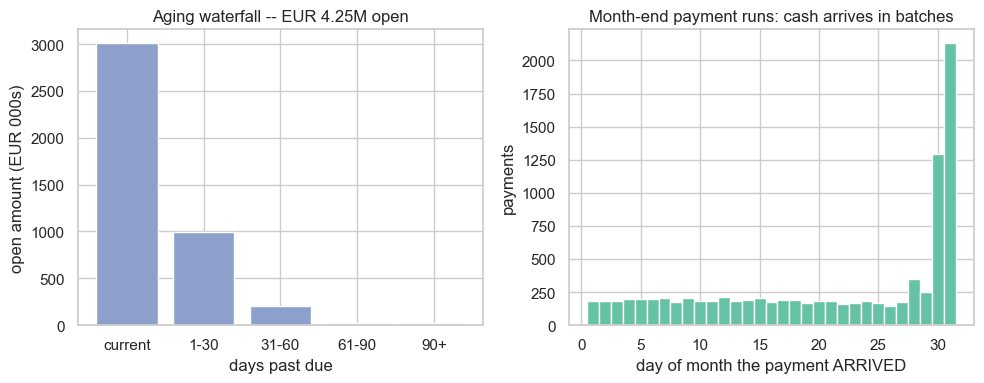

In [4]:
# FIG 1 -- the waterfall, and the quirk that will haunt every daily forecast
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(aging.index.astype(str), aging["sum"] / 1000, color="#8da0cb")
axes[0].set_xlabel("days past due"); axes[0].set_ylabel("open amount (EUR 000s)")
axes[0].set_title(f"Aging waterfall -- EUR {book.amount.sum() / 1e6:.2f}M open")

paid_hist = ledger.dropna(subset=["paid_date"])
axes[1].hist(paid_hist.paid_date.dt.day, bins=np.arange(0.5, 32), color="#66c2a5")
axes[1].set_xlabel("day of month the payment ARRIVED")
axes[1].set_ylabel("payments")
axes[1].set_title("Month-end payment runs: cash arrives in batches")
plt.tight_layout()

Three readings before anyone touches a model:

- **The book is EUR 4.25M and DSO is ~60 days** on average terms of ~33 days. The gap — nearly four weeks — is lateness plus the June quarter-end surge sitting undigested in the *current* bucket. On this book, **one day of DSO is ~€70k of cash**: shave four days off and you've freed more than the entire €250k buffer without selling anything.
- **The waterfall is front-loaded but not clean.** ~71 % of the book isn't due yet; the 1–30 bucket is fat (a million euros of "slightly late" is normal B2B life); and the 31+ tail — some €255k — is where disputes and tomorrow's write-offs live.
- **The right panel is the quirk to respect.** Payments don't arrive when customers "should" pay; they arrive **when payment runs execute** — see the spike at day 28–31. Any forecast that promises cash on a specific *day* is fiction for 40 % of this book. That is why everything below forecasts **weeks**, and why §5's evaluation would collapse into noise at daily grain.


---

### ✋ Quick exercise (~2 min) — read the waterfall like a CFO

Using the numbers printed above: (a) how much cash would a **4-day DSO reduction** free, and how does that compare to the €250k buffer? (b) What share of the open book is *actually overdue* (not just open)? (c) If history says ~4 % of invoices that go 30+ days late end as write-offs, what's a back-of-envelope expected loss hiding in the 31+ buckets?


In [5]:
# ✍️ Your turn 👇
# freed = 4 * one_dso_day
# overdue_share = ... (everything except the 'current' bucket, from `aging`)
# rough_expected_loss = 0.04 * (31-60 + 61-90 + 90+ balances)

<details>
<summary>✅ <b>Solution</b></summary>

```python
freed = 4 * one_dso_day
overdue = aging["sum"].drop("current")
rough_el = 0.04 * aging["sum"].loc[["31-60", "61-90", "90+"]].sum()
print(f"4 DSO days frees      EUR {freed:,.0f}  ({freed / BUFFER:.1f}x the buffer)")
print(f"overdue share of book : {overdue.sum() / aging['sum'].sum():.1%}  (EUR {overdue.sum():,.0f})")
print(f"expected loss in 31+  : ~EUR {rough_el:,.0f}")
```

Four DSO days ≈ **€281k** — more than the whole buffer, which is why collections is a treasury function and not an admin chore. About **29 %** of the book is overdue in the everyday sense. And the 31+ expected loss is a rounding error next to the timing question — on this book, *when* dwarfs *whether*. That ordering (timing first, credit loss second) is the difference between this notebook and A3.
</details>


## 2. When will this invoice pay? Predicting days-late

The unit of prediction is one invoice; the target is `days_late` (payment date minus due date, negative = early). Everything hangs on **feature discipline**: for an invoice issued on 12 March, the model may only know what the company knew on 12 March. That means the customer's payment history must be reconstructed **as of the issue date** — prior invoices *settled by then*, their mean lateness, how many were sitting overdue that morning — exactly NB 26's shifted-rolling-window rule, with invoices instead of days. The single most tempting column in the ledger (`reminders_sent`) is also the most poisonous; it goes in the exercises, not the feature list, and 🧪 Exercise 3 dissects what happens to the colleague who used it.

The split respects time, as always: **train on months 1–14** (issued before March 2025), **test on months 15–18** — invoices that have actually settled by today. (The last Net 60 invoices from June haven't resolved yet; a real system handles that censoring with survival models — §6 — while we note it and move on.)


In [6]:
def as_of_features(ledger):
    """Customer payment history AS OF each invoice's issue date. No peeking:
    an invoice's features use only payments that had ARRIVED before it was issued."""
    df = ledger.sort_values(["customer_id", "issue_date"]).reset_index(drop=True)
    n = len(df)
    prior_n, open_over = np.zeros(n), np.zeros(n)
    prior_mean, prior_s30, prior_me = (np.full(n, np.nan) for _ in range(3))
    for _, g in df.groupby("customer_id", sort=False):
        idx = g.index.to_numpy()
        iss, due = g.issue_date.to_numpy(), g.due_date.to_numpy()
        paid, late = g.paid_date.to_numpy(), g.days_late.to_numpy()
        me = g.paid_date.dt.is_month_end.fillna(False).to_numpy()
        for k, i in enumerate(idx):
            settled = paid[:k] <= iss[k]              # NaT compares False -> excluded
            prior_n[i] = settled.sum()
            if settled.any():
                prior_mean[i] = np.nanmean(late[:k][settled])
                prior_s30[i] = np.nanmean(late[:k][settled] > 30)
                prior_me[i] = me[:k][settled].mean()  # month-end payer fingerprint
            open_over[i] = ((due[:k] < iss[k]) & ~settled).sum()   # overdue THAT morning
    df["prior_n"], df["prior_mean_late"] = prior_n, prior_mean
    df["prior_share_30"], df["prior_open_overdue"] = prior_s30, open_over
    df["prior_me_share"] = prior_me
    return df

feat = as_of_features(ledger)
feat["log_amount"] = np.log(feat.amount)
feat["size_num"] = feat["size"].map({"small": 0, "mid": 1, "large": 2})
feat["month"] = feat.issue_date.dt.month
feat["qe_issue"] = (feat.issue_date.dt.month.isin([3, 6, 9, 12])
                    & (feat.issue_date.dt.day > 20)).astype(int)
feat["due_to_month_end"] = (feat.due_date.dt.to_period("M").dt.end_time.dt.normalize()
                            - feat.due_date).dt.days      # for the batch payers

FEATURES = ["terms", "log_amount", "size_num", "month", "qe_issue", "due_to_month_end",
            "prior_n", "prior_mean_late", "prior_share_30", "prior_open_overdue",
            "prior_me_share"]

SPLIT = pd.Timestamp("2025-03-01")
train = feat[(feat.issue_date < SPLIT) & (feat.paid_date <= TODAY)]
test = feat[(feat.issue_date >= SPLIT) & (feat.paid_date <= TODAY)]
print(f"train {len(train):,} invoices (months 1-14) / test {len(test):,} (months 15-18, settled)")
feat.loc[feat.customer_id == feat.customer_id.value_counts().idxmax(),
         ["issue_date", "amount", "days_late", "prior_n", "prior_mean_late",
          "prior_open_overdue"]].iloc[8:13]   # watch the history accumulate, invoice by invoice

train 6,915 invoices (months 1-14) / test 1,277 (months 15-18, settled)


,issue_date,amount,days_late,prior_n,prior_mean_late,prior_open_overdue
2513,2024-02-29,3056.36,23.0,0.0,NaN,4.0
2514,2024-03-05,1660.38,-3.0,1.0,15.000000,3.0
2515,2024-03-17,6082.33,33.0,3.0,17.333333,2.0
2516,2024-03-30,3714.04,22.0,5.0,17.800000,3.0
2517,2024-04-09,1852.57,5.0,8.0,14.875000,3.0


### 🔮 Predict the output

Three forecasters are about to be scored on test-set MAE (in days):

1. **"Everyone pays on the due date"** — predict `days_late = 0`. The CFO's spreadsheet, formalized.
2. **"The customer's historical mean"** — one `groupby` in disguise: predict `prior_mean_late` (global mean for first-timers).
3. **Gradient boosting** on all eleven features, trained to minimize absolute error.

Rank them before running — and commit to a *gap*: how many days does the model beat the customer-mean baseline by? (For scale: baseline 1's error is the average |lateness| in the book, ~15 days.)


In [7]:
global_mean = train.days_late.mean()
mae_due = test.days_late.abs().mean()                          # predicting zero
mae_cust = mean_absolute_error(test.days_late, test.prior_mean_late.fillna(global_mean))

reg = HistGradientBoostingRegressor(loss="absolute_error", random_state=0)
reg.fit(train[FEATURES], train.days_late)
mae_model = mean_absolute_error(test.days_late, reg.predict(test[FEATURES]))

print(f"MAE 'pays on due date'     : {mae_due:5.2f} days   <- the spreadsheet")
print(f"MAE customer's own mean    : {mae_cust:5.2f} days   <- one groupby")
print(f"MAE gradient boosting      : {mae_model:5.2f} days   <- eleven features, 100 trees")

MAE 'pays on due date'     : 15.33 days   <- the spreadsheet
MAE customer's own mean    :  9.32 days   <- one groupby
MAE gradient boosting      :  8.59 days   <- eleven features, 100 trees


The ordering is what you expected; the *gaps* are the lesson. Going from the due-date fiction to the customer's own mean buys **~6 days of MAE** — the single biggest jump available, from one `groupby`. Eleven features of machine learning buy **less than one more day**. That ratio is not an indictment of the model; it is the structure of the problem: **in AR, persistence is the signal.** Who the customer is explains most of what's predictable; everything else (amount effects, month-end mechanics, quarter-end drag) is real but second-order. When a vendor demos an "AI payment prediction engine", the honest question is exactly the one you just computed: *by how much does it beat the customer's own average?*

(A technical note that matters: the model minimizes **absolute** error — `loss="absolute_error"` — so it predicts a conditional *median*. With a dispute tail this skewed, a squared-loss model chases means it can't earn and quietly loses to the one-line baseline. Try it.)

For decisions we also need probabilities, not just point estimates: §3 will want *P(this invoice goes 30+ days late)* — and NB 18's rule applies unchanged: a probability you can't calibrate is a probability you can't spend.


AUC 0.85 | base rate 21.1% | n test 1,022

calibration by decile (%):
        pred   obs
decile            
0        0.6   3.9
1        1.3   3.9
2        1.9   5.9
3        3.0   8.8
4        4.4   7.8
5        6.8   6.9
6       12.0  11.8
7       24.4  32.4
8       50.6  52.0
9       85.4  77.7


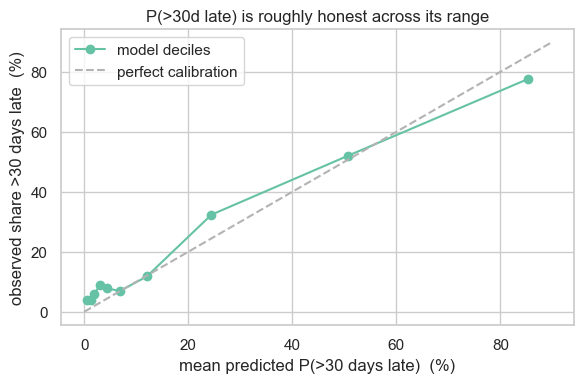

In [8]:
# P(>30 days late) -- classifier on the same features, calibration checked
# training labels include write-offs (they are the far end of "late");
# invoices still open and not yet adjudicable are EXCLUDED (censoring, honestly).
tr_c = feat[(feat.issue_date < SPLIT)
            & ((feat.paid_date <= TODAY) | feat.paid_date.isna())].copy()
tr_c["late30"] = ((tr_c.days_late > 30) | tr_c.paid_date.isna()).astype(int)

te_c = feat[(feat.issue_date >= SPLIT)
            & (feat.due_date <= TODAY - pd.Timedelta(days=31))].copy()  # label determined
te_c["late30"] = ((te_c.days_late > 30) | te_c.paid_date.isna()).astype(int)

clf = HistGradientBoostingClassifier(random_state=0).fit(tr_c[FEATURES], tr_c.late30)
p30 = clf.predict_proba(te_c[FEATURES])[:, 1]
print(f"AUC {roc_auc_score(te_c.late30, p30):.2f} | base rate {te_c.late30.mean():.1%} "
      f"| n test {len(te_c):,}")

cal = (pd.DataFrame({"pred": p30, "obs": te_c.late30.to_numpy()})
       .groupby(pd.qcut(p30, 10, labels=False, duplicates="drop")).mean() * 100)
print("\ncalibration by decile (%):")
print(cal.round(1).rename_axis("decile").to_string())

# FIG 2 -- calibration: can we SPEND these probabilities?
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cal["pred"], cal["obs"], "-o", color="#66c2a5", label="model deciles")
lim = max(cal.max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="#b3b3b3", label="perfect calibration")
ax.set_xlabel("mean predicted P(>30 days late)  (%)")
ax.set_ylabel("observed share >30 days late  (%)")
ax.set_title("P(>30d late) is roughly honest across its range")
ax.legend(); plt.tight_layout()

Ranking is strong (AUC ≈ 0.85 against a ~21 % base rate) and the deciles hug the diagonal well enough to *spend*: the top decile predicts ~85 % and delivers ~78 %, the bottom predicts ~1 % and delivers ~4 %. Slight over-confidence at the extremes, honest in the middle — good enough for a call queue, and we'll treat the residual miscalibration as noise rather than tuning it away on the test set (the threshold decisions in §3 come from *economics*, not from this sample).


## 3. The collections queue — NB 24's move, wearing finance clothes

Two collectors, 40 calls a week, ~125 chaseable invoices worth ~€0.6M (overdue by 5+ days, not yet in the 90+ legal pile). This is *exactly* NB 24's alert queue: a capacity, a ranked list, and euros deciding the order. The instinctive rankings — and what every AR tool ships as default — are **by amount** ("chase the big ones") or **by days overdue** ("chase the old ones"). Both are wrong, and they're wrong in a way you can price.

A call is worth what it *changes*. If it succeeds (55 %), payment arrives ~12 days earlier and the write-off tail gets a haircut (early contact catches disputes and quiet insolvencies while there's still something to collect — we'll assume a successful call cuts write-off risk by 30 %, an assumption a real team would A/B test, A2-style). So the expected value of calling invoice $i$:

$$\text{EV}_i = p_{\text{succ}} \times \Big(\underbrace{A_i \cdot r_{\text{day}} \cdot \min(12,\ \widehat{D}_i)}_{\text{cash-acceleration value}} + \underbrace{0.30 \cdot \widehat{p}^{\text{wo}}_i \cdot A_i}_{\text{write-off risk trimmed}}\Big) - \underbrace{15}_{\text{the call}}$$

where $\widehat{D}_i$ is the *predicted days until payment* — an invoice about to be swept up in Friday's payment run gains nothing from a phone call, however large it is. That term is where the amount-ranking dies: the model's job in this section is not to predict lateness, it is to predict **which lateness a call can still change**. (One crudeness, admitted up front: for badly overdue invoices the issue-time model's predicted date has already passed, and we floor $\widehat D_i$ at two days. §4 handles "it hasn't paid yet" properly by conditioning; Stretch C feeds that conditioning back into this queue.)


In [9]:
# refit on ALL settled history as of today -- the split was for measurement (NB 18);
# production models use every label that exists this morning
settled = feat[feat.paid_date <= TODAY]
reg_live = HistGradientBoostingRegressor(loss="absolute_error", random_state=0).fit(
    settled[FEATURES], settled.days_late)
hist_c = feat[(feat.paid_date <= TODAY) | feat.paid_date.isna()].copy()
hist_c["late30"] = ((hist_c.days_late > 30) | hist_c.paid_date.isna()).astype(int)
clf_live = HistGradientBoostingClassifier(random_state=0).fit(hist_c[FEATURES], hist_c.late30)

# the chaseable book: overdue 5-90 days (90+ is the dunning ladder / legal, not the phone)
book_f = feat[open_now.reindex(feat.index, fill_value=False)].copy()
book_f["dpd"] = (TODAY - book_f.due_date).dt.days
chase = book_f[(book_f.dpd >= 5) & (book_f.dpd <= 90)].copy()

chase["pred_late"] = reg_live.predict(chase[FEATURES])
chase["p30"] = clf_live.predict_proba(chase[FEATURES])[:, 1]
p_wo_g30 = hist_c.paid_date.isna()[hist_c.late30 == 1].mean()   # P(write-off | went 30+ late)
chase["p_wo"] = (chase.p30 * p_wo_g30).clip(0, 0.6)

pred_pay = chase.due_date + pd.to_timedelta(np.round(chase.pred_late), unit="D")
chase["exp_remaining"] = ((pred_pay - TODAY).dt.days).clip(lower=2)   # still-unpaid floor

pull = np.minimum(CALL_PULL, chase.exp_remaining)
chase["ev_call"] = (P_SUCCESS * (chase.amount * R_DAY * pull
                                 + 0.30 * chase.p_wo * chase.amount) - CALL_COST)

print(f"chaseable book: {len(chase)} invoices, EUR {chase.amount.sum():,.0f}")
print(f"historical P(write-off | went 30+ days late): {p_wo_g30:.1%}")

chaseable book: 125 invoices, EUR 616,931
historical P(write-off | went 30+ days late): 5.2%


In [10]:
# ---- three ways to spend 40 calls ----
queues = {"by expected value": chase.nlargest(CALLS_PER_WEEK, "ev_call"),
          "by amount": chase.nlargest(CALLS_PER_WEEK, "amount"),
          "by days overdue": chase.nlargest(CALLS_PER_WEEK, "dpd")}

ev_q = queues["by expected value"]
print(f"{'queue (40 calls)':<20}{'net EV / week':>14}{'-> per quarter':>16}"
      f"{'overlap w/ EV queue':>22}")
for name, q in queues.items():
    ov = len(set(q.index) & set(ev_q.index))
    print(f"{name:<20}{q.ev_call.sum():>12,.0f} EUR{13 * q.ev_call.sum():>13,.0f} EUR"
          f"{ov:>15}/40")

print("\nMonday's call list -- top 8 by expected value:")
cols = ["customer_id", "amount", "dpd", "pred_late", "exp_remaining", "p_wo", "ev_call"]
print(ev_q[cols].head(8).round(2).to_string(index=False))

print("\n...and the invoices an amount-ranked queue would call first:")
print(queues["by amount"][cols].head(3).round(2).to_string(index=False))

queue (40 calls)     net EV / week  -> per quarter   overlap w/ EV queue
by expected value            113 EUR        1,469 EUR             40/40
by amount                    -58 EUR         -751 EUR             22/40
by days overdue             -294 EUR       -3,817 EUR             12/40

Monday's call list -- top 8 by expected value:
 customer_id   amount  dpd  pred_late  exp_remaining  p_wo  ev_call
         580 11805.01   63      32.88              2  0.05    86.72
         586 44406.16    6      18.46             12  0.00    53.79
         551  5521.22   40      42.86              3  0.05    29.53
         551  5254.30   21      39.90             19  0.04    25.89
         551  4729.32   38      40.15              2  0.05    23.04
         521  4416.68   63      33.40              2  0.05    20.30
         589  4697.33   34      24.10              2  0.04    15.94
         581  3644.47   66      34.51              2  0.05    13.77

...and the invoices an amount-ranked queue would c

Read the two lists against each other — this is the classic trap, dissected:

- **Only one of the three queues is above water.** Same two collectors, same 40 dials: the EV ordering nets **+€113/week (≈ +€1.5k per quarter)**; ranking by amount nets **−€58/week**, and ranking by days overdue **−€294/week (≈ −€3.8k per quarter)** — the two default sort buttons in every AR tool *lose money at these economics*. The spread between best and worst ordering is ~€5.3k/quarter of pure sort key.
- **Big is not the same as changeable.** The amount queue's #1 (€44.4k, 6 days overdue, ~12 predicted days of delay left to compress, negligible write-off risk) happens to be a decent call — it sits near the top of the EV list too. But its #2 and #3 — €32k and €30.5k, both predicted to land within days, `p_wo ≈ 0` — are **negative EV**: €15 spent accelerating money that was already on its way, most likely inside a month-end payment run.
- **The best call is a €11.8k chronic offender at 63 dpd** with a ~5 % write-off probability (EV ≈ +€87): almost all of its value is the *tail term*. At 8 % cost of capital, twelve days of interest on even a large invoice is coffee money — a collections call is really an **insurance premium on the write-off tail**, with cash acceleration as the side dish. (Also note customer 551 holding three of the top eight slots: in practice that's one call, three invoices — batching by *customer* is the first refinement a real team makes.)
- **Age measures how long you've failed to collect, not what a call is worth now.** The days-overdue queue fills up with small, disputed, half-dead paper where €15 buys nothing.

It's NB 23's uplift lesson in miniature: **rank by what the action changes, not by the size of the problem.** And one honesty note: the 12-days/55 % call effect is an *assumed* treatment effect. A4 taught you what that sentence should trigger — hold out a random slice of the queue and measure it.


---

### ✋ Quick exercise (~2 min) — price one call by hand

An invoice: **€24,000**, predicted to pay in **30 more days**, write-off probability **3 %**. Compute the expected value of calling it (use the constants; write-off haircut 30 %). Then recompute for its evil twin: **€45,000**, predicted to pay in **2 days**, write-off probability ~0. Which one earns its €15?


In [11]:
# ✍️ Your turn 👇
# ev = P_SUCCESS * (amount * R_DAY * min(CALL_PULL, days_remaining)
#                   + 0.30 * p_wo * amount) - CALL_COST

<details>
<summary>✅ <b>Solution</b></summary>

```python
for label, amt, d_rem, p_wo in [("chronic mid-size", 24_000, 30, 0.03),
                                ("big but imminent", 45_000, 2, 0.0)]:
    ev = P_SUCCESS * (amt * R_DAY * min(CALL_PULL, d_rem) + 0.30 * p_wo * amt) - CALL_COST
    print(f"{label}: EV = {ev:+7.2f} EUR")
```

The €24k chronic invoice is worth ~**+€139**: ~€35 of pure acceleration (12 days × €24k × 8 %/365 × 55 %) plus ~€119 of trimmed tail risk. The €45k invoice about to be swept up in a payment run: the call can only pull `min(12, 2) = 2` days → ~€11 gross, **−€4 net**. Notice where the value actually lives: at 8 % cost of capital, the *interest* on twelve days is coffee money — the queue is really an **insurance operation on the write-off tail**, with cash acceleration as a side dish. That's why `p_wo` calibration (§2) mattered.
</details>


## 4. From invoices to the cash curve — the 13-week forecast

Now the CFO's actual question. A 13-week cash forecast — the treasury industry's standard horizon, long enough to act (arrange funding, delay spend) and short enough to model invoice-by-invoice — needs two inflow layers plus the outflows:

- **Layer A — the open book, scored invoice by invoice.** For each of the ~800 open invoices we need not a payment *date* but a payment-date **distribution**: the model's point prediction plus a residual drawn from the training residuals — *truncated at today*, because for an invoice that's already overdue, "it hasn't paid yet" is information (the gentle version of a survival model; §6 names the full one). Write-offs happen with probability $\hat p^{wo}_i$, escalated for the 90+ tail using historical roll rates.
- **Layer B — invoices that don't exist yet.** Sales in the next 13 weeks will become cash partly inside the window. Weekly issuance is forecast with NB 26's **seasonal-naive** — same week one *quarter* ago, since this business breathes quarterly — and converted to cash timing with the historical, **amount-weighted** collection profile (share of invoiced euros landing $k$ weeks after issue; amount-weighted because big invoices pay slower, and cash counts euros, not invoices).
- **Outflows** are boringly deterministic and that's fine: suppliers €355k/week, payroll €245k on the last banking day of the month, VAT prepayment €330k due 10 July. Deterministic outflows + stochastic inflows = the whole tension of treasury.

Why distributions instead of the model's (good!) point estimates? Because the CFO's question is about a **quantile of a sum**, and sums of point forecasts have no quantiles. We'll compute the point-forecast version too, and watch it miss the risk that matters.


In [12]:
H = 13  # weeks

def train_models(feat, asof):
    """Delay + late30 models on invoices settled (or adjudicated) before `asof`."""
    tr = feat[(feat.issue_date < asof) & (feat.paid_date < asof)]
    reg = HistGradientBoostingRegressor(loss="absolute_error", random_state=0).fit(
        tr[FEATURES], tr.days_late)
    resid = np.sort(tr.days_late.to_numpy() - reg.predict(tr[FEATURES]))
    trc = feat[(feat.issue_date < asof) & ((feat.paid_date < asof)
               | (feat.due_date < asof - pd.Timedelta(days=180)))].copy()
    late30 = ((trc.days_late > 30) | trc.paid_date.isna()).astype(int)
    clf = HistGradientBoostingClassifier(random_state=0).fit(trc[FEATURES], late30)
    wo_g30 = trc.paid_date.isna()[late30 == 1].mean()
    return reg, resid, clf, wo_g30, tr

def open_book_at(feat, asof):
    m = ((feat.issue_date <= asof) & (feat.paid_date.isna() | (feat.paid_date > asof))
         & ((asof - feat.due_date).dt.days < 180))
    return feat[m].copy()

def collection_profile(tr, asof, kmax=20):
    """Share of invoiced CASH landing k weeks after issue (amount-weighted; seasoned
    cohorts only -- recent cohorts are censored toward fast payers)."""
    d = tr[tr.issue_date < asof - pd.Timedelta(days=120)]
    wk = ((d.paid_date - d.issue_date).dt.days // 7).clip(0, kmax)
    return (d.amount.groupby(wk).sum() / d.amount.sum()).reindex(
        range(kmax + 1), fill_value=0.0).to_numpy()

def issuance_seasonal_naive(feat, asof, h=H):
    """Weekly invoiced amount = same week one quarter (13 weeks) ago. NB 26's baseline."""
    wk = feat[feat.issue_date < asof].set_index("issue_date").amount.resample(
        "W-MON", label="left", closed="left").sum()
    idx = pd.date_range(asof, periods=h, freq="7D")
    return np.array([wk.get(d - pd.Timedelta(weeks=13), wk.tail(13).mean()) for d in idx])

def simulate_inflows(feat, asof, n_sims=2000, seed=1):
    """Monte Carlo weekly inflows: (open-book matrix, new-invoice matrix), sims x weeks."""
    rng = np.random.default_rng(seed)
    reg_a, resid, clf_a, wo_g30, tr = train_models(feat, asof)
    bk = open_book_at(feat, asof)
    n = len(bk)
    pred = reg_a.predict(bk[FEATURES])
    p_wo = np.clip(clf_a.predict_proba(bk[FEATURES])[:, 1] * wo_g30, 0, 0.5)
    # roll-rate escalation: an invoice already 90+ dpd carries the historical
    # write-off rate of invoices that reached 90+ -- not its issue-time score
    dpd = (asof - bk.due_date).dt.days.to_numpy()
    hist = feat[feat.issue_date < asof]
    reach90 = (hist.days_late > 90) | hist.paid_date.isna()
    p_wo = np.where(dpd > 90, np.maximum(p_wo, hist.paid_date.isna()[reach90].mean()), p_wo)

    # ---- layer A: truncated residual sampling ("it hasn't paid yet" is data) ----
    base = (bk.due_date - asof).dt.days.to_numpy() + pred      # predicted days from asof
    lo = np.searchsorted(resid, -base)                         # first residual > threshold
    u = rng.random((n_sims, n))
    ridx = np.minimum((lo[None, :] + u * (len(resid) - lo[None, :])).astype(int),
                      len(resid) - 1)
    days = base[None, :] + resid[ridx]
    hopeless = lo >= len(resid)                                # nothing in history fits
    if hopeless.any():
        days[:, hopeless] = rng.exponential(14, (n_sims, hopeless.sum()))
    alive = rng.random((n_sims, n)) >= p_wo[None, :]
    wk_mat = np.floor(days / 7).astype(int)
    amounts = bk.amount.to_numpy()
    inflow_open = np.zeros((n_sims, H))
    for w in range(H):
        inflow_open[:, w] = ((wk_mat == w) & alive) @ amounts

    # ---- layer B: seasonal-naive issuance x collection profile ----
    iss, prof = issuance_seasonal_naive(feat, asof), collection_profile(tr, asof)
    wo_share = hist.amount[hist.paid_date.isna()].sum() / hist.amount.sum()
    new_exp = np.zeros(H)
    for j in range(H):
        for k in range(H - j):
            new_exp[j + k] += iss[j] * prof[k]
    new_exp *= 1 - wo_share
    inflow_new = new_exp[None, :] * rng.normal(1.0, 0.10, (n_sims, H)).clip(0.6, 1.4)
    return inflow_open, inflow_new, bk, pred, p_wo

inflow_open, inflow_new, bk4, pred4, p_wo4 = simulate_inflows(feat, TODAY)
weeks = pd.date_range(TODAY, periods=H, freq="7D")
print("expected inflow, EUR 000s per week (rounded):")
print(pd.DataFrame({"open book": inflow_open.mean(0) / 1000,
                    "new invoices": inflow_new.mean(0) / 1000},
                   index=[d.strftime("%d %b") for d in weeks]).round(0).T.to_string())

expected inflow, EUR 000s per week (rounded):
              30 Jun  07 Jul  14 Jul  21 Jul  28 Jul  04 Aug  11 Aug  18 Aug  25 Aug  01 Sep  08 Sep  15 Sep  22 Sep
open book      421.0   417.0   403.0   371.0   457.0   439.0   434.0   275.0   294.0   202.0   194.0   109.0    75.0
new invoices     2.0     6.0    14.0    29.0    59.0   117.0   188.0   223.0   273.0   352.0   366.0   361.0   409.0


median minimum cash: EUR 293,259, reached in week 2
P(cash dips below the EUR 250,000 buffer at any point) = 25%
expected shortfall if it happens: EUR 39,756

treasury policy (draw if P(breach) > 10%): DRAW the credit line this week


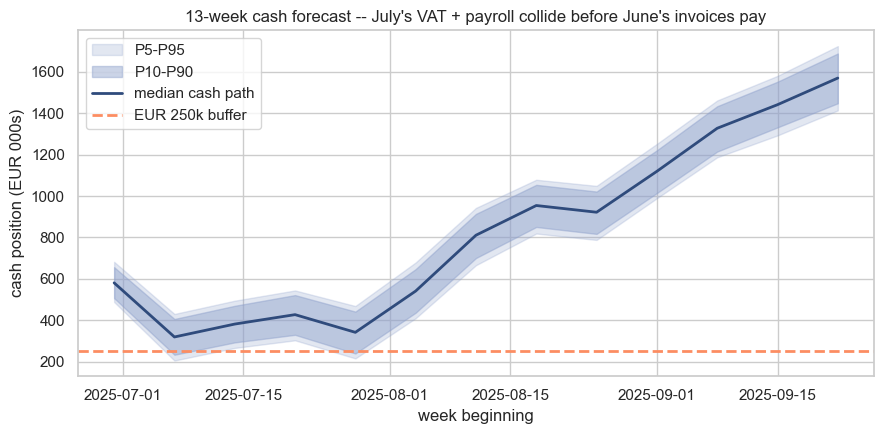

In [13]:
# ---- outflows, cash position, and the CFO's number ----
outflow = np.full(H, 355_000.0)                                # suppliers, weekly
for i, w0 in enumerate(weeks):
    days_in_week = pd.date_range(w0, w0 + pd.Timedelta(days=6))
    if any(d.is_month_end for d in days_in_week):
        outflow[i] += 245_000                                  # payroll
    if any((d.month in (1, 4, 7, 10)) and d.day == 10 for d in days_in_week):
        outflow[i] += 330_000                                  # quarterly VAT prepayment

cash = START_CASH + np.cumsum(inflow_open + inflow_new - outflow[None, :], axis=1)
min_cash = cash.min(axis=1)
p_breach = (min_cash < BUFFER).mean()
worst_week = int(np.median(cash.argmin(axis=1))) + 1

# FIG 3 -- the fan chart: one picture, one decision
fig, ax = plt.subplots(figsize=(9, 4.5))
lo10, med, hi90 = np.percentile(cash, [10, 50, 90], axis=0)
lo5, hi95 = np.percentile(cash, [5, 95], axis=0)
ax.fill_between(weeks, lo5 / 1000, hi95 / 1000, color="#8da0cb", alpha=0.25, label="P5-P95")
ax.fill_between(weeks, lo10 / 1000, hi90 / 1000, color="#8da0cb", alpha=0.45, label="P10-P90")
ax.plot(weeks, med / 1000, color="#2f4b7c", lw=2, label="median cash path")
ax.axhline(BUFFER / 1000, color="#fc8d62", ls="--", lw=2, label=f"EUR {BUFFER / 1000:.0f}k buffer")
ax.set_ylabel("cash position (EUR 000s)"); ax.set_xlabel("week beginning")
ax.set_title("13-week cash forecast -- July's VAT + payroll collide before June's invoices pay")
ax.legend(loc="upper left"); plt.tight_layout()

print(f"median minimum cash: EUR {np.median(min_cash):,.0f}, reached in week {worst_week}")
print(f"P(cash dips below the EUR {BUFFER:,.0f} buffer at any point) = {p_breach:.0%}")
print(f"expected shortfall if it happens: "
      f"EUR {np.mean(np.maximum(BUFFER - min_cash, 0)[min_cash < BUFFER]):,.0f}")
policy = "DRAW the credit line this week" if p_breach > 0.10 else "no draw needed"
print(f"\ntreasury policy (draw if P(breach) > 10%): {policy}")

In [14]:
# ---- the same forecast the point-estimate way: sum of best guesses ----
pt_days = np.maximum((bk4.due_date - TODAY).dt.days.to_numpy() + pred4, 2)
pt_in = np.zeros(H)
wkp = np.floor(pt_days / 7).astype(int)
for w in range(H):
    pt_in[w] = bk4.amount.to_numpy()[wkp == w].sum()
pt_in *= 1 - p_wo4.mean()                       # even granting it a write-off haircut
cash_pt = START_CASH + np.cumsum(pt_in + inflow_new.mean(0) - outflow)

print(f"point-forecast minimum cash : EUR {cash_pt.min():,.0f} (week {cash_pt.argmin() + 1})"
      f"  -> 'comfortably above the buffer'")
print(f"Monte Carlo median minimum  : EUR {np.median(min_cash):,.0f} (week {worst_week})")
print(f"Monte Carlo P5 minimum      : EUR {np.percentile(min_cash, 5):,.0f}")
print(f"P(breach) under point logic : 0%   |   actual P(breach): {p_breach:.0%}")

point-forecast minimum cash : EUR 422,106 (week 4)  -> 'comfortably above the buffer'
Monte Carlo median minimum  : EUR 293,259 (week 2)
Monte Carlo P5 minimum      : EUR 184,988
P(breach) under point logic : 0%   |   actual P(breach): 25%


This is the **forecast-of-the-sum** lesson, and it's worth slowing down for:

- The point forecast says the minimum is ~**€420k** — clear of the buffer, sleep well. It gets there by placing every invoice at its *single most likely* week, which lets the errors silently cancel. But errors only cancel **on average**; the buffer question is about the **bad tail**, where late payments cluster (a payment run slips, a big account drifts, the batchers all roll into next month *together*).
- The Monte Carlo answer: median minimum ~**€293k** — already lower, because conditioning overdue invoices on "still unpaid" pushes their cash later — and **P(breach) ≈ 25 %**, a one-in-four quarter. The point forecast didn't underestimate the *expectation*; it had no concept of the *question*.
- The decision comes from policy, not vibes: treasury draws the line when P(breach) exceeds 10 %. At ~25 % with an expected shortfall around €40k, the answer is **draw** (or: run §3's queue hard for two weeks and re-forecast — pulling a few hundred k forward is exactly what changes this number; the two sections are one system).

A decision, in euros, with a probability attached — that's what "cash forecast" means when it's done as engineering rather than as a spreadsheet ritual.


---

### ✋ Quick exercise (~2 min) — read the band like a treasurer

From the `cash` matrix: (a) compute the probability of being below the buffer **in week 2 specifically**, and compare it to the P(breach-at-any-point) printed above — why must the running-minimum number be larger? (b) The credit line costs 0.75 % commitment fee on a €300k draw for the quarter — is insurance at that price worth it against the expected shortfall?


In [15]:
# ✍️ Your turn 👇
# p_week2 = (cash[:, 1] < BUFFER).mean()
# fee = 0.0075 * 300_000
# expected_shortfall_unconditional = np.maximum(BUFFER - min_cash, 0).mean()

<details>
<summary>✅ <b>Solution</b></summary>

```python
p_week2 = (cash[:, 1] < BUFFER).mean()
p_any = (cash.min(axis=1) < BUFFER).mean()
fee = 0.0075 * 300_000
es_uncond = np.maximum(BUFFER - min_cash, 0).mean()
print(f"P(below buffer in week 2)     : {p_week2:.0%}")
print(f"P(below buffer at ANY point)  : {p_any:.0%}  (>= any single week, always)")
print(f"commitment fee EUR {fee:,.0f} vs unconditional expected shortfall EUR {es_uncond:,.0f}")
```

The any-point probability dominates every single-week probability because the running minimum takes the *worst* of thirteen correlated draws — the same reason A2's "peeking" inflated false positives. And the fee (~€2.3k) buys off an expected shortfall several times larger, *plus* the un-modelled cost of an emergency draw at panic pricing. Cheap insurance; the analysis's job was to show the risk was real, not to be clever about avoiding the fee.
</details>


## 5. Backtest the forecast honestly — four past Mondays

A forecast you've never backtested is an opinion with axes. The honest procedure is the walk-forward you know from NB 26: **stand at a historical Monday, use only what was knowable that morning** — models retrained on invoices settled *by then*, the open book *as it stood*, seasonal-naive issuance from history — forecast 13 weeks, then step forward and compare against realized cash. We do it from four Mondays (November through February, spanning a year-end), and we bring a challenger: the **due-date forecast** — every open invoice pays on its due date (or immediately, if already overdue), every future invoice pays exactly on `issue + terms`, nobody defaults. That is, politely, the spreadsheet most finance teams run their liquidity on.


In [16]:
MONDAYS = [pd.Timestamp(d) for d in ("2024-11-04", "2024-12-02", "2025-01-06", "2025-02-03")]

def realized_weekly(feat, asof, h=H):
    p = feat.dropna(subset=["paid_date"])
    w = (p.paid_date - asof).dt.days // 7
    m = (w >= 0) & (w < h)
    return p[m].groupby(w[m]).amount.sum().reindex(range(h), fill_value=0.0).to_numpy()

def due_date_forecast(feat, asof, h=H):
    """The spreadsheet: due dates are payment dates, defaults don't exist."""
    bk = open_book_at(feat, asof)
    land = bk.due_date.where(bk.due_date > asof, asof + pd.Timedelta(days=3))
    w = (land - asof).dt.days // 7
    m = (w >= 0) & (w < h)
    fc = bk[m].groupby(w[m]).amount.sum().reindex(range(h), fill_value=0.0).to_numpy().copy()
    iss = issuance_seasonal_naive(feat, asof, h)
    lag = int(round(feat[feat.issue_date < asof].terms.mean() / 7))   # ~5 weeks
    for j in range(h - lag):
        fc[j + lag] += iss[j]
    return fc

rows, ae_model, ae_due = [], [], []
for mon in MONDAYS:
    io, iw, *_ = simulate_inflows(feat, mon, n_sims=500, seed=mon.toordinal())
    fc_model = io.mean(0) + iw.mean(0)
    fc_due = due_date_forecast(feat, mon)
    real = realized_weekly(feat, mon)
    ae_model.append(np.abs(fc_model - real)); ae_due.append(np.abs(fc_due - real))
    rows.append([mon.date(), real.sum(), fc_model.sum() - real.sum(), fc_due.sum() - real.sum()])
    print(f"{mon.date()}  realized 13w cash {real.sum():>10,.0f} | "
          f"model {fc_model.sum() - real.sum():>+9,.0f} | due-date {fc_due.sum() - real.sum():>+11,.0f}")

ae_model, ae_due = np.array(ae_model), np.array(ae_due)
bias_model = np.mean([r[2] for r in rows]); bias_due = np.mean([r[3] for r in rows])
print(f"\naverage 13-week bias -- model   : {bias_model:>+11,.0f} EUR")
print(f"average 13-week bias -- due-date: {bias_due:>+11,.0f} EUR   <- structurally optimistic")

2024-11-04  realized 13w cash  6,196,370 | model   -17,358 | due-date  +1,905,631


2024-12-02  realized 13w cash  6,213,588 | model  -235,929 | due-date  +1,048,819


2025-01-06  realized 13w cash  6,465,941 | model   -95,523 | due-date  +1,285,526


2025-02-03  realized 13w cash  6,627,893 | model  -134,182 | due-date  +1,736,619

average 13-week bias -- model   :    -120,748 EUR
average 13-week bias -- due-date:  +1,494,149 EUR   <- structurally optimistic


model    weekly MAE: weeks 1-4  241,346 -> weeks 9-13  277,111 EUR
due-date weekly MAE: weeks 1-4  530,379 -> weeks 9-13  158,247 EUR


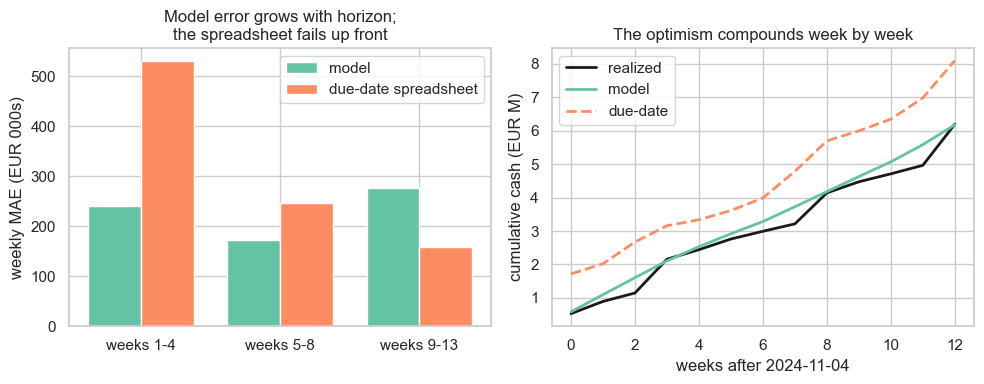

In [17]:
# horizon decay + the bias picture
buckets = {"weeks 1-4": slice(0, 4), "weeks 5-8": slice(4, 8), "weeks 9-13": slice(8, 13)}
mae_h_model = {k: ae_model[:, s].mean() for k, s in buckets.items()}
mae_h_due = {k: ae_due[:, s].mean() for k, s in buckets.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(3)
axes[0].bar(x - 0.19, [v / 1000 for v in mae_h_model.values()], 0.38,
            color="#66c2a5", label="model")
axes[0].bar(x + 0.19, [v / 1000 for v in mae_h_due.values()], 0.38,
            color="#fc8d62", label="due-date spreadsheet")
axes[0].set_xticks(x, list(buckets)); axes[0].set_ylabel("weekly MAE (EUR 000s)")
axes[0].set_title("Model error grows with horizon;\nthe spreadsheet fails up front"); axes[0].legend()

mon0 = MONDAYS[0]
io0, iw0, *_ = simulate_inflows(feat, mon0, n_sims=500, seed=mon0.toordinal())
real0 = realized_weekly(feat, mon0)
axes[1].plot(np.cumsum(real0) / 1e6, color="k", lw=2, label="realized")
axes[1].plot(np.cumsum(io0.mean(0) + iw0.mean(0)) / 1e6, color="#66c2a5", lw=2, label="model")
axes[1].plot(np.cumsum(due_date_forecast(feat, mon0)) / 1e6, color="#fc8d62",
             lw=2, ls="--", label="due-date")
axes[1].set_xlabel(f"weeks after {mon0.date()}"); axes[1].set_ylabel("cumulative cash (EUR M)")
axes[1].set_title("The optimism compounds week by week"); axes[1].legend()
plt.tight_layout()

print(f"model    weekly MAE: weeks 1-4 {mae_h_model['weeks 1-4']:>8,.0f} -> "
      f"weeks 9-13 {mae_h_model['weeks 9-13']:>8,.0f} EUR")
print(f"due-date weekly MAE: weeks 1-4 {mae_h_due['weeks 1-4']:>8,.0f} -> "
      f"weeks 9-13 {mae_h_due['weeks 9-13']:>8,.0f} EUR")

What the four Mondays certify:

- **The model is honest.** Its 13-week totals land between −€17k and −€236k of realized cash — average bias **−€121k on ~€6.4M (≈ 2 %, on the conservative side)**, which is the sign of error a treasurer forgives. Weekly errors grow from ~€241k near-term to ~€277k at the far horizon: weeks 1–4 are mostly the known open book; weeks 9–13 are mostly invoices that didn't exist on forecast day, so the seasonal-naive layer's uncertainty dominates. Knowing *which* weeks to trust is part of the deliverable.
- **The due-date forecast is optimistic by ~€1.5M per quarter — every quarter.** Not noisy: *biased*. It books cash at due dates that lateness will miss (~15 days of drift on the whole book), counts Net 60 money that slides past week 13, and collects from the ~1 % who will never pay. And look *where* its weekly error sits: **€530k in weeks 1–4** (every overdue invoice booked as instant cash) against €158k far out — it is most wrong in exactly the weeks treasury has to act on, while its smooth-looking far weeks quietly accumulate the €1.5M of bias (right panel). If treasury plans on it, the gap gets bridged by the credit line at the worst possible moment — and called a forecasting surprise instead of what it is, an accounting *assumption*.
- Said politely in the Monday meeting: *"the spreadsheet answers 'what are customers contractually supposed to do'; the model answers 'what do customers like ours actually do'. The €1.5M between those two sentences is why we keep both — one for chasing, one for planning."*


## 6. What real treasury & FP&A systems add (honest section)

Everything above is the load-bearing 80 %. The remaining 20 %, honestly listed:

- **Payment-run calendars and remittance data.** Real systems know that customer X executes payment runs on the 25th and month-end, and parse remittance advice ("we'll pay invoices 4711+4712 on Friday") from emails and bank files. That converts our *statistical* month-end spike into per-customer *scheduled* cash — the single biggest accuracy upgrade available, and it comes from plumbing, not modelling. (Our `prior_me_share` feature is the poor man's version.)
- **Survival models for the open book.** Our truncated-residual trick is a hand-rolled discrete-time survival model. The grown-up version (Kaplan–Meier curves per segment, gradient-boosted hazards) handles censoring natively — the invoices we had to *exclude* from training, a survival model would learn from.
- **The 13-week convention.** Why 13? One quarter: long enough to cover a covenant test date and arrange funding (drawing a line takes days; renegotiating one takes months), short enough that invoice-level modelling beats driver-based guessing. Beyond 13 weeks, real FP&A switches to **driver-based planning** (revenue plans × collection profiles — our layer B, at coarser grain) and stops pretending to see individual invoices.
- **Credit-line mechanics.** Real lines have commitment fees, drawn margins, cleanup periods, and **covenants** (e.g. minimum liquidity tested monthly) — the buffer isn't a preference, it's often a contract. Breaching a covenant because your forecast was due-date-optimistic is a genuinely expensive way to learn §5.
- **FX and payment rails.** Multi-currency books add hedging; SEPA vs SWIFT vs card settlement adds 0–3 days of rail latency that has nothing to do with customer behaviour. Both are modelled as separate layers, not smeared into the delay model.
- **Collections beyond phone calls.** The full **dunning ladder**: friendly reminder → formal *Mahnung* → interest charges → collection agency → legal — each rung with its own cost, success rate, and relationship damage, which turns §3's one-shot EV into a sequential policy (NB 23's campaign maths, escalated). Plus **factoring** (sell receivables at a discount — Stretch D prices it) and **dynamic discounting**: offer *2/10 net 30* — 2 % off for paying in 10 days. Worked one-liner: the customer who takes it earns 2 % for 20 days ≈ **36.7 % annualized** (`0.02/0.98 × 365/20`), so against our 8 % cost of capital, *offering* it is expensive cash — rational only when the line is exhausted or the buyer's risk is worse than the discount. ✋ below makes you run the number.
- **What this notebook deliberately did not solve:** the call effect (12 days, 55 %) is assumed, not measured — A4 says randomize a holdout; invoice-level *dispute prediction* (our +52-day tail) is its own classifier in mature systems; and the revenue layer deserves better than seasonal-naive once promotions and pipeline data exist (NB 26's lag-feature regression is the natural upgrade).


---

### ✋ Quick exercise (~2 min) — the 2/10 net 30 arithmetic

A customer owes **€60,000** on net 30. You consider offering *2/10 net 30*. (a) What annualized return does the customer earn by taking it? (b) What does the offer cost you in euros, and what do you gain if your alternative is an overdraft at 9.5 %, assuming this customer usually pays ~15 days **late** (so you'd get cash ~35 days earlier)? Decide: offer it or not?


In [18]:
# ✍️ Your turn 👇
# customer's annualized return = (0.02 / 0.98) * (365 / 20)
# your cost = 0.02 * 60_000 ; your funding saved = 60_000 * 0.095 / 365 * 35

<details>
<summary>✅ <b>Solution</b></summary>

```python
cust_annual = 0.02 / 0.98 * 365 / 20
cost = 0.02 * 60_000
saved = 60_000 * 0.095 / 365 * 35
print(f"customer's implied annual return: {cust_annual:.1%}")
print(f"your cost EUR {cost:,.0f} vs overdraft interest saved EUR {saved:,.0f}")
```

The customer earns **~37 % annualized** — which is why any customer with cash takes the discount, always. You pay **€1,200** to save **~€546** of overdraft interest: a losing trade at these rates, even against 9.5 % funding. Dynamic discounting earns its keep only when the acceleration window is bigger, the funding squeeze is acute (a covenant week!), or the payer's write-off risk is high enough that 98 % *now* beats a 96 %-expected *later*. Same formula as §3's queue — cash-acceleration value plus tail-risk value versus price — just with the price tag at 2 % instead of €15.
</details>


## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | A3's approvals became an AR book; aging + DSO price the problem | EUR 4.25M open, DSO ~60d, **1 DSO day = ~EUR 70k** |
| 1 | Month-end payment runs make daily forecasts fiction | the day-28-31 spike → we forecast **weeks** |
| 2 | Days-late model with as-of features, time-aware split | MAE: due-date **15.3** → customer mean **9.3** → model **8.6** days |
| 2 | The baseline is the headline | one `groupby` buys ~6 days; ML buys <1 more — **persistence is the signal** |
| 3 | 40 calls ranked by expected cash change, not amount/age | EV queue **+EUR 1.5k/qtr**; amount **−0.8k**; age **−3.8k** — only one is above water |
| 3 | The trap: biggest overdue ≠ best call | EUR 45k imminent-payer: **−EUR 4** per call; EUR 24k chronic: **+EUR 139** |
| 4 | Per-invoice payment *distributions* → 13-week fan chart | median min cash ~EUR 293k, **P(breach buffer) ≈ 25 %** → draw the line |
| 4 | Sum of point forecasts has no tail | point logic says min EUR ~420k, P(breach) "0 %" |
| 5 | Walk-forward from four Mondays | model bias ~**−EUR 0.1M**; weekly MAE 240k → 280k with horizon |
| 5 | The due-date spreadsheet, measured | **+EUR 1.5M optimistic per quarter**, structurally |
| 6 | 2/10 net 30, priced | taking it = **37 % annualized**; offering it rarely beats 8 % capital |


## 🧪 Practice exercises

### Exercise 1 — ⭐ The as-of audit

Pick the customer with the most invoices. For their **12th invoice**, recompute `prior_n`, `prior_mean_late` and `prior_open_overdue` by hand — masks on `ledger`, no helper function — and verify they match the columns in `feat`. Then explain in one sentence why `paid_date <= issue_date` (not `issue_date_of_prior < issue_date`) is the condition that keeps the feature honest.


In [19]:
# Starter
cid = feat.customer_id.value_counts().idxmax()
g = feat[feat.customer_id == cid].sort_values("issue_date").reset_index(drop=True)
target = g.iloc[11]          # the 12th invoice
# prior = ledger rows for cid with paid_date <= target.issue_date ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
cid = feat.customer_id.value_counts().idxmax()
g = feat[feat.customer_id == cid].sort_values("issue_date").reset_index(drop=True)
target = g.iloc[11]
earlier = ledger[(ledger.customer_id == cid) & (ledger.issue_date < target.issue_date)]
settled = earlier[earlier.paid_date <= target.issue_date]
open_over = earlier[(earlier.due_date < target.issue_date)
                    & ~(earlier.paid_date <= target.issue_date)]
print(f"by hand : n={len(settled)}, mean_late={settled.days_late.mean():.2f}, "
      f"open_overdue={len(open_over)}")
print(f"in feat : n={target.prior_n:.0f}, mean_late={target.prior_mean_late:.2f}, "
      f"open_overdue={target.prior_open_overdue:.0f}")
```

They match. The condition is on **`paid_date`**, because an invoice issued earlier but *paid later* had an unknown `days_late` on the morning we're reconstructing — using it would smuggle the future into the feature. "Information known at prediction time" is a statement about when the *outcome* arrived, not when the *row* was created — the same distinction that made NB 26 shift its rolling windows and NB 23 hunt post-outcome columns.
</details>

### Exercise 2 — ⭐⭐ The payment-run fingerprint

Detect the batch payers from payments alone: flag customers where ≥ 50 % of settled payments landed on a month-end date (require ≥ 5 payments). Check your detector against the planted `batcher` column. Then compare the §2 model's test MAE on invoices from detected batchers vs the rest. Is the model *better* or *worse* on batchers — and why does the answer depend on which month-end the payment rolls to?


In [20]:
# Starter
paid_all = ledger.dropna(subset=["paid_date"])
me_share = (paid_all.paid_date.dt.is_month_end).groupby(paid_all.customer_id).mean()
n_paid = paid_all.groupby("customer_id").size()
# detected = customers with me_share >= 0.5 and n_paid >= 5 ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
paid_all = ledger.dropna(subset=["paid_date"])
me_share = paid_all.paid_date.dt.is_month_end.groupby(paid_all.customer_id).mean()
n_paid = paid_all.groupby("customer_id").size()
detected = set(me_share[(me_share >= 0.5) & (n_paid >= 5)].index)

truth = ledger.groupby("customer_id").batcher.first()
flag = truth.index.to_series().isin(detected).astype(int)
print(f"detected {len(detected)} batchers | agreement with ground truth: "
      f"{(flag == truth).mean():.1%}")

is_b = test.customer_id.isin(detected)
pred_t = reg.predict(test[FEATURES])
for label, m in [("batchers", is_b), ("others", ~is_b)]:
    print(f"MAE {label:9s}: {mean_absolute_error(test.days_late[m], pred_t[m]):.2f} days "
          f"(n={m.sum()})")
```

Detection agrees with the planted truth ~94 % of the time — a payment-run habit is the loudest fingerprint in the ledger. And the model is markedly *worse* on batchers (by nearly three days of MAE) despite their mechanical behaviour, because the target is **bimodal**: an invoice due on the 20th pays at *this* month-end (+11 days) or, if the run cutoff was missed, at the *next* (+41). A median-loss model must pick one mode and eats the full gap when wrong. That bimodality is irreducible at the invoice level and is exactly why real systems buy the payment-run *calendar* (§6) instead of a better loss function.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the collections model that knew the payment date

A colleague "improved" §2's model with a feature already sitting in the ledger export — `reminders_sent` — and reported a breakthrough. Their pipeline runs below without error and the MAE is spectacular. Reproduce it, explain precisely how the leak works (the dunning system is *honest software* — where does the future sneak in?), and state the fix. Would the production model, scoring a fresh invoice on issue day, see any benefit?


In [21]:
# Starter -- their exact pipeline (it runs fine; that is the point)
LEAKY = FEATURES + ["reminders_sent"]
reg_leak = HistGradientBoostingRegressor(loss="absolute_error", random_state=0).fit(
    train[LEAKY], train.days_late)
mae_leak = mean_absolute_error(test.days_late, reg_leak.predict(test[LEAKY]))
print(f"MAE with reminders_sent: {mae_leak:.2f} days -- 'huge improvement, ship it!'??")

MAE with reminders_sent: 3.44 days -- 'huge improvement, ship it!'??


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"leaky test MAE : {mae_leak:.2f} days")
print(f"honest test MAE: {mae_model:.2f} days")
print(ledger.groupby("reminders_sent").days_late.agg(["mean", "count"]).round(1))
```

`reminders_sent` in the export is `floor(days_late / 14)` — a **photograph of the counter at settlement**. The dunning system is honest; the *snapshot* isn't: the ledger stores the counter's final value, which is a staircase function of the target. Given the feature, the model only has to place the payment within a 14-day window — hence MAE ≈ 3.4. On issue day every invoice has `reminders_sent = 0`, so the production model gains nothing; worse, it has learned to lean on a column that is constant at scoring time, so it *underperforms* the honest model exactly when it's needed. The fix is the as-of rule from §2: either drop the column, or reconstruct it **as of the feature date** (for scoring open invoices mid-life, `floor(clip(days_overdue_so_far,0)/14)` *is* knowable — a legitimate feature for §3's queue, an illegitimate one for issue-day prediction). Same disease as NB 23's post-outcome columns and NB 26's unshifted windows: **ask when each column's value became known.**
</details>

### Exercise 4 — ⭐⭐ Terms are a lever, too

Collections attacks lateness; the *terms mix* attacks the other 33 days. Simulate moving every Net 60 invoice to Net 30, assuming customers keep the same lateness *relative to the due date* (so their payments shift 30 days earlier). Recompute the open book at `TODAY` and DSO. How much cash does it free, using §1's €/DSO-day — and what's the one-sentence reason the CFO can't just do it?


In [22]:
# Starter -- work on a COPY of ledger
sim = ledger.copy()
is60 = sim.terms == 60
# shift due_date and paid_date back 30 days for Net-60 invoices; recompute open book, DSO

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
sim = ledger.copy()
is60 = sim.terms == 60
sim.loc[is60, "due_date"] -= pd.Timedelta(days=30)
sim.loc[is60, "paid_date"] -= pd.Timedelta(days=30)
open_sim = ((sim.issue_date <= TODAY) & (sim.paid_date.isna() | (sim.paid_date > TODAY))
            & ((TODAY - sim.due_date).dt.days < 180))
book_sim = sim.amount[open_sim].sum()
dso_sim = book_sim / sales_12m * 365
print(f"book: EUR {book.amount.sum():,.0f} -> EUR {book_sim:,.0f} "
      f"(freed EUR {book.amount.sum() - book_sim:,.0f})")
print(f"DSO : {dso:.1f} -> {dso_sim:.1f} days ({dso - dso_sim:.1f} days x "
      f"EUR {one_dso_day:,.0f} = EUR {(dso - dso_sim) * one_dso_day:,.0f})")
```

Roughly **€400–500k** freed permanently — several times what §3's call queue accelerates in a quarter, from a contract clause rather than a phone. The reason the CFO can't just do it: **Net 60 customers are the large accounts, and terms were part of the price** — tighten them unilaterally and you're re-running A1's pricing problem with churn attached. (The grown-up version: *offer* the switch paired with a small discount and price it with the ✋ 2/10 arithmetic — or A/B it, A2.)
</details>


## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Shrink the league table

`prior_mean_late` on 2 invoices is gossip; on 40 it's a fact. Build the shrunken estimator $\tilde\mu_i = \frac{n_i \bar x_i + k\, \mu_g}{n_i + k}$ (customer mean pulled toward the global mean, weight $k$), choose $k$ on a **validation window inside train** (invoices issued Jan–Feb 2025), and compare raw vs shrunk customer-mean baselines on the §2 test set — overall and for customers with `prior_n <= 3`. This is hierarchical/empirical-Bayes shrinkage, the same maths that fixes small-sample league tables.


In [23]:
# Starter -- sketch:
# val = feat issued in [2025-01-01, SPLIT), settled; grid k in 1..30 (k=0 IS the raw baseline)
# shrunk = (prior_n * prior_mean_late + k * global_mean) / (prior_n + k)
# pick k by val MAE; evaluate on `test`, then on test[test.prior_n <= 3]

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
val = feat[(feat.issue_date >= "2025-01-01") & (feat.issue_date < SPLIT)
           & (feat.paid_date <= TODAY)]
gm_fit = feat[(feat.issue_date < "2025-01-01") & (feat.paid_date <= TODAY)].days_late.mean()

def shrunk_pred(d, k, gm):
    n, m = d.prior_n, d.prior_mean_late.fillna(gm)
    return (n * m + k * gm) / (n + k)

ks = np.arange(1, 31)          # k=0 divides by zero for first-timers -- and IS the raw baseline
val_mae = [mean_absolute_error(val.days_late, shrunk_pred(val, k, gm_fit)) for k in ks]
k_star = int(ks[np.argmin(val_mae)])
print(f"chosen on validation: k = {k_star}")

for label, d in [("all test", test), ("prior_n <= 3", test[test.prior_n <= 3])]:
    raw = mean_absolute_error(d.days_late, d.prior_mean_late.fillna(global_mean))
    shr = mean_absolute_error(d.days_late, shrunk_pred(d, k_star, global_mean))
    print(f"{label:14s}: raw {raw:5.2f} -> shrunk {shr:5.2f} days")
```

The chosen $k$ is small (here $k=1$: one pseudo-invoice of global behaviour, then the customer's own record takes over — with per-customer noise σ ≈ 8–10 days against wide between-customer spread, even two real invoices already beat the prior). Overall the gain is barely visible (persistence was already strong), but on thin-history customers the shrunken estimate wins by over half a day, because the raw mean there is mostly noise. Two course echoes: this is *exactly* why the GBM beat the raw baseline (trees blend customer history with population structure automatically), and note the discipline — $k$ was tuned on **validation**, never on test.
</details>

### Stretch exercise B — ⭐⭐⭐ The P90 payment date

Treasury doesn't plan on medians. Fit a **quantile regressor** (`HistGradientBoostingRegressor(loss="quantile", quantile=0.9)`) for the 90th percentile of `days_late`. Verify coverage on the test set (≈ 90 % of invoices should pay by their P90 date), check it per size segment, and rebuild §4's point-forecast cash curve with P90 delays: a deterministic *pessimistic* curve. Where does it sit relative to the Monte Carlo P10 band — and why are they *not* the same thing?


In [24]:
# Starter -- sketch:
# q90 = HistGradientBoostingRegressor(loss="quantile", quantile=0.9, random_state=0)
# coverage = (test.days_late <= q90.predict(test[FEATURES])).mean()
# cash curve: land each open invoice at due + q90 days, cumulate like the pt_in cell

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
q90 = HistGradientBoostingRegressor(loss="quantile", quantile=0.9, random_state=0).fit(
    train[FEATURES], train.days_late)
cov = (test.days_late <= q90.predict(test[FEATURES])).mean()
print(f"P90 coverage on test: {cov:.1%} (target ~90%)")
for s in ["small", "mid", "large"]:
    m = test["size"] == s
    print(f"  {s:6s}: {(test.days_late[m] <= q90.predict(test[m][FEATURES])).mean():.1%}")

d90 = np.maximum((bk4.due_date - TODAY).dt.days.to_numpy()
                 + q90.predict(bk4[FEATURES]), 2)
in90 = np.zeros(H)
wk90 = np.floor(d90 / 7).astype(int)
for w in range(H):
    in90[w] = bk4.amount.to_numpy()[wk90 == w].sum()
cash90 = START_CASH + np.cumsum(in90 * (1 - p_wo4.mean()) + inflow_new.mean(0) - outflow)
print(f"P90-delay curve minimum : EUR {cash90.min():,.0f}")
print(f"Monte Carlo P10 minimum : EUR {np.percentile(min_cash, 10):,.0f}")
```

Coverage lands on target overall (~90 %); the large segment undershoots a little — its delays are so regular that the P90 sits on a knife-edge where a single day's granularity moves coverage by points, and there are fewer invoices to average over. The P90-delay curve dives far *below* the MC P10 minimum — negative, in fact — it's the **more** pessimistic object, because it assumes every invoice *simultaneously* hits its personal 90th percentile, an event with probability far below 10 % across 800 quasi-independent invoices. Per-invoice quantiles ≠ portfolio quantiles — the same forecast-of-the-sum lesson as §4, mirrored. Use per-invoice P90s for *conversations about single big invoices*; use the simulation for the *portfolio* question.
</details>

### Stretch exercise C — ⭐⭐⭐ Not who to call — *when*

§3 ranked invoices; a better team also *times* them. For each invoice in the EV queue, estimate `p_soon` = P(it pays within 7 days anyway | still open) from the truncated-residual machinery (share of admissible residuals landing within 7 days). A call placed on an invoice that pays this week is wasted with probability `p_soon`. Split this Monday's 40 calls into **call now** vs **wait a week** using the rule "wait if `p_soon > CALL_COST / EV_gross`", and quantify the euros saved per quarter.


In [25]:
# Starter -- sketch:
# reg_t, resid_t, *_ = train_models(feat, TODAY)   (or reuse reg_live + its residuals)
# base_i = (due - TODAY).days + pred_late_i ; admissible resid > -base_i
# p_soon_i = share of admissible residuals with base_i + r <= 7

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
reg_t, resid_t, clf_t, wo_t, tr_t = train_models(feat, TODAY)
q = ev_q.copy()
base_q = (q.due_date - TODAY).dt.days.to_numpy() + reg_t.predict(q[FEATURES])
lo_q = np.searchsorted(resid_t, -base_q)
p_soon = np.array([
    (resid_t[l:] + b <= 7).mean() if l < len(resid_t) else 0.0
    for l, b in zip(lo_q, base_q)])
ev_gross = q.ev_call.to_numpy() + CALL_COST
wait = p_soon > CALL_COST / np.maximum(ev_gross, 1e-9)
saved = (p_soon * CALL_COST)[wait].sum()
print(f"call now: {(~wait).sum()} invoices | wait a week: {wait.sum()}")
print(f"expected waste avoided: EUR {saved:,.0f}/week -> EUR {13 * saved:,.0f}/quarter")
```

A handful of the 40 get benched — typically batcher invoices sitting just before a month-end run, exactly the ones §3 already priced low. The euro saving is small (the EV ranking had *already* pushed pays-anyway invoices down the list), and that's the finding: **ranking by expected change absorbs most of the timing decision for free.** The residual timing gain matters more in bigger teams, where the queue digs deeper into ambiguous territory — and the real upgrade is a *renewal* view: re-score the whole book every Monday, so "wait" is just "let next week's queue decide".
</details>

### Stretch exercise D — ⭐⭐⭐ Price the factoring offer with A3's loss numbers

A factor offers **non-recourse factoring** on invoices ≤ 60 dpd: they pay you 100 % minus a **2.5 % fee**, now, and eat any default. Using each open invoice's `exp_remaining` and `p_wo` (recovery on written-off B2B invoices ≈ 35 %, i.e. A3's LGD = 0.65): sell invoice $i$ iff $0.025\,A_i < A_i r_{day} \widehat D_i + 0.65\,\hat p^{wo}_i A_i$. How many invoices — and how many euros — are worth selling? What does the factor's fee *implicitly* charge for, and why does the answer connect back to A3's `PD*`?


In [26]:
# Starter -- sketch:
# elig = book_f[(book_f.dpd <= 60)] with pred_late / p30 / p_wo like SS3 (or reuse `chase`)
# sell = FEE < carry + 0.65 * p_wo  (all per euro of face value)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
FEE = 0.025
elig = book_f[book_f.dpd <= 60].copy()
elig["pred_late"] = reg_live.predict(elig[FEATURES])
elig["p_wo"] = (clf_live.predict_proba(elig[FEATURES])[:, 1] * p_wo_g30).clip(0, 0.6)
d_rem = ((elig.due_date + pd.to_timedelta(np.round(elig.pred_late), unit="D") - TODAY)
         .dt.days.clip(lower=2))
value_of_selling = R_DAY * d_rem + 0.65 * elig.p_wo          # per euro of face
sell = value_of_selling > FEE
print(f"worth selling: {sell.sum()} of {len(elig)} invoices, "
      f"EUR {elig.amount[sell].sum():,.0f} of EUR {elig.amount.sum():,.0f}")
print(f"avg p_wo of sold: {elig.p_wo[sell].mean():.1%} vs kept: {elig.p_wo[~sell].mean():.1%}")
```

Only a thin, ugly slice clears the bar: at 8 % capital, 2.5 % flat needs ~114 days of carry to pay for itself on *time value* alone, so the invoices worth selling are the ones where the **0.65 × p_wo term** does the work — the high-risk tail. Which is precisely what the factor's fee prices: they run A3's calculation from the other side (their fee ≥ their `PD × LGD` + margin on *your* book). Factoring is a market where you sell your left tail to someone with a better scorecard — if selling looks broadly attractive, what you've actually discovered is that your own A3 model is underestimating `p_wo`. Selection bias, wearing a term sheet.
</details>


## 🎁 Bonus mini-project — the Monday treasury one-pager

Write `monday_pack()` that produces the single page the CFO reads before the 9:00 call, every number traceable to a cell above:

1. **The position:** cash today, open AR (aging waterfall with week-over-week deltas), DSO and its 4-week trend, write-offs booked this month.
2. **The 13-week view:** the fan chart, the minimum-cash week, **P(breach €250k)** with the expected shortfall, and the standing policy line ("draw if P > 10 %") with this week's verdict — plus the model-vs-due-date bias from the latest backtest, so the number's credibility is on the page with the number.
3. **The queue:** this week's 40 calls (customer, amount, dpd, predicted remaining delay, EV), expected acceleration in euros, and last week's queue *results* (calls made, promises kept) — the feedback loop that will eventually replace the assumed 12-days/55 % with measured values (A4's holdout says how).
4. **Decisions requested:** anything the model can't decide — the two disputes older than 60 days, the Net-60-to-Net-30 proposal from 🧪 Exercise 4 with its €400k prize and its churn risk, the factoring quote from Stretch D.

Format it with an f-string; schedule it with NB 46's patterns; draft the commentary with NB 28 if you like. Grading yourself: a treasurer who has never seen Python should be able to act on every line — and challenge any line, because each one names its source (ledger fact, model output, or assumption).


## ✅ Self-assessment checklist

- [ ] I can read an aging waterfall, compute DSO, and price **one day of DSO** in cash for a given book.
- [ ] I build customer-history features **as of the issue date** — and I can say precisely why the condition is on `paid_date`, not `issue_date`.
- [ ] I name my baselines before my model: *due date* and *customer mean* — and I know the customer mean is the one to respect.
- [ ] I know a squared-loss model predicts means, an absolute-loss model predicts medians, and which one a skewed delay distribution punishes.
- [ ] I check calibration before spending a probability (NB 18), and I never tune decision thresholds on the test set.
- [ ] I rank a collections queue by **expected change in euros** — cash acceleration plus tail-risk reduction, minus the call — and can explain why the biggest overdue invoice is often a bad call.
- [ ] I forecast cash as a **distribution of a sum**, not a sum of point forecasts, and I can state what the point version structurally cannot see.
- [ ] I condition on "still unpaid" when scoring an open invoice (and I know the grown-up name for this: a survival model).
- [ ] I backtest forecasts **walk-forward**, report error by horizon, and quantify bias separately from noise.
- [ ] I can quantify, in euros per quarter, why a due-date cash forecast is structurally optimistic — and say it politely.
- [ ] I can do the *2/10 net 30* arithmetic from memory and know when offering it beats drawing the line.
- [ ] I know which parts of this notebook were assumptions (the call effect) and what experiment would replace them (A2/A4).

---

> 🧭  [◀ A5 — People Analytics](./A5_people_analytics.ipynb)  ·  [Module 7 index](./README.md)  ·  [A7 — Sales Pipeline & Forecast ▶](./A7_sales_pipeline.ipynb)  ·  [🏠 Course home](../README.md)
